In [ ]:
from openmm.app import *
from openmm import *
from openmm.unit import *
from sys import stdout
from openmmtools.integrators import LangevinIntegrator, LangevinSplittingGirsanov
import matplotlib

from deeptime.decomposition import TICA

import numpy as np
from matplotlib import pyplot as plt

from deeptime.clustering import MiniBatchKMeans
from deeptime.markov import TransitionCountEstimator
from deeptime.markov.msm import MaximumLikelihoodMSM
from deeptime.plots import plot_implied_timescales
from deeptime.util.validation import implied_timescales
from deeptime.markov import GirsanovReweightingEstimator

from scipy.linalg import eig
from scipy.stats import gaussian_kde
from pymbar import MBAR

import gc

from potential import *

In [2]:
def build_MSM(msm_lagtime,assignments):
    counts = TransitionCountEstimator(lagtime=msm_lagtime, count_mode='sliding').fit_fetch(assignments)
    msm = MaximumLikelihoodMSM().fit_fetch(counts)
    return msm

def Girsanov_MSM(msm_lagtime,assignments,reweighting_factors,stationary_pi=None):
    count_estimator = GirsanovReweightingEstimator(lagtime=msm_lagtime,count_mode='sliding')
    counts = count_estimator.fit(data=assignments,reweighting_factors=reweighting_factors).fetch_model()
    if stationary_pi is not None:
        msm = MaximumLikelihoodMSM(stationary_distribution_constraint=stationary_pi).fit_fetch(counts)
    else:
        msm = MaximumLikelihoodMSM().fit_fetch(counts)
    return msm

# We need to further modify assignments_unbiased and assignments_biased
def reorganize_indices(assignments,n_microstates):
    populated_states = np.unique(assignments)
    empty_states = []
    assignments_new = np.zeros(assignments.shape,dtype=np.int32)
    shift = 0
    for idx in range(n_microstates):
        if idx in populated_states:
            idx_new = idx - shift
            assignments_new[np.where(assignments == idx)] = idx_new
        else:
            empty_states.append(idx)
            shift += 1
    return assignments_new, empty_states

def reorganize_eigenvectors(msm,msm_ref,n_eigenvectors,n_microstates,empty_states):
    eigenvectors_new = np.zeros((n_microstates,n_eigenvectors))
    shift = 0
    for idx in range(n_microstates):
        if idx in empty_states:
            shift += 1
            empty_entries = np.zeros(n_eigenvectors,)
            # Let values of eigenvectors being nan for plotting
            empty_entries[:] = np.nan
            eigenvectors_new[idx,:] = empty_entries
        else:
            idx_new = idx - shift
            pi_idx = msm.stationary_distribution[idx_new]
            ev_idx = msm.eigenvectors_right()[idx_new,1:n_eigenvectors]
            eigenvectors_new[idx,:] = np.concatenate([[pi_idx],ev_idx])
    # Align each eigenvector with the reference eigenvector
    for i in range(1,n_eigenvectors):
        if np.nansum(np.abs(-eigenvectors_new[:,i] - msm_ref.eigenvectors_right()[:,i])) < np.nansum(np.abs(eigenvectors_new[:,i] - msm_ref.eigenvectors_right()[:,i])):
            eigenvectors_new[:,i] = -eigenvectors_new[:,i]
    return eigenvectors_new

# We first compute the u_kn matrix
def us_bias(x,x0_k,k_spring):
    return 0.5 * k_spring * (x - x0_k)**2

def us_mbar_input(x,x0,k_spring,n_samples_per_window,unbiased=True,temp=310):
    kt = 8.314 * temp / 1000
    if unbiased == True:
        u_kn = np.zeros((len(x0)+1,len(x)))
        for k,x0_k in enumerate(x0):
            u_kn[k+1] = us_bias(x,x0_k,k_spring) / kt
        N_k = np.ones(n_windows+1,) * n_samples_per_window
        N_k[0] = 0
    else:
        u_kn = np.zeros((len(x0),len(x)))
        for k,x0_k in enumerate(x0):
            u_kn[k] = us_bias(x,x0_k,k_spring) / kt
        N_k = np.ones(n_windows,) * n_samples_per_window
    return u_kn,N_k

In [3]:
# matplotlib fonts
# matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.size'] = 20

### 1d Quadrawell potential

In [4]:
# Load data
name = '1d_quadrawell'
systemforce = QuadraWellForce()

data_ref = np.load('traj_and_dat/{name}/unbiased_10x1000000.npy'.format(name=name))

n_repeats = 10

data_us = []
data_rerun = []
data_build_up = []
data_smd = []

for n_re in range(n_repeats):
    data_us.append(
        np.load('traj_and_dat/{name}/umbrella_sampling/50x2000_k=100_umbrella_sampling_{n_re}.npy'.format(
            n_re = n_re, name = name
        ))[:,:500,:]
    )

    data_rerun.append(
        np.load('traj_and_dat/{name}/metad_rerun/100000_gamma=2_metad_rerun_{n_re}.npy'.format(
            n_re = n_re, name = name
        ))[:25000,:]
    )

    data_build_up.append(
        np.load('traj_and_dat/{name}/metad_build_up/100000_gamma=2_metad_build_up_{n_re}.npy'.format(
            n_re = n_re, name = name
        ))[:25000,:]
    )

    data_smd.append(
        np.load('traj_and_dat/{name}/steered_md/100000_v_pulling=0.0016_steered_md_{n_re}.npy'.format(
            n_re = n_re, name = name
        ))[:25000,:]
    )

In [5]:
# Grid Discretization
from deeptime.clustering import BoxDiscretization

data_ref_concat = np.concatenate(data_ref,axis=0)

# Construct grid box
dim = 1
n_boxes = 25                        # hence 25x25=625 grid boxes
v0 = np.array([-0.9])
v1 = np.array([0.9])

grid_box = BoxDiscretization(
    dim=1,  # the number of dimensions the data lives in
    n_boxes=n_boxes,  # number of boxes per axis (can also be single int for all axes)
    v0=v0,
    v1=v1
)

n_microstates = n_boxes**dim
microstates = grid_box.fit(data_ref_concat.reshape(-1,1)).fetch_model()
# Unbiased Reference
assignments_ref = microstates.transform(data_ref_concat.reshape(-1,1)).reshape(data_ref.shape)

assignments_us = []
assignments_rerun = []
assignments_build_up = []
assignments_smd = []

for n_re in range(n_repeats):
    
    # Umbrella Sampling
    assignments_us_n = microstates.transform(np.concatenate(data_us[n_re][:,:,0], axis=0).reshape(-1,1)).reshape(data_us[n_re][:,:,0].shape)
    assignments_us_n, empty_states_us_n = reorganize_indices(assignments_us_n,n_microstates)
    assignments_us.append((assignments_us_n, empty_states_us_n))

    # MetaD Rerun
    assignments_rerun_n = microstates.transform(data_rerun[n_re][:,0].reshape(-1,1)).reshape(data_rerun[n_re][:,0].shape)
    assignments_rerun_n, empty_states_rerun_n = reorganize_indices(assignments_rerun_n,n_microstates)
    assignments_rerun.append((assignments_rerun_n, empty_states_rerun_n))

    # MetaD Build-up
    assignments_build_up_n = microstates.transform(data_build_up[n_re][:,0].reshape(-1,1)).reshape(data_build_up[n_re][:,0].shape)
    assignments_build_up_n, empty_states_build_up_n = reorganize_indices(assignments_build_up_n,n_microstates)
    assignments_build_up.append((assignments_build_up_n, empty_states_build_up_n))

    # Steered MD
    assignments_smd_n = microstates.transform(data_smd[n_re][:,0].reshape(-1,1)).reshape(data_smd[n_re][:,0].shape)
    assignments_smd_n, empty_states_smd_n = reorganize_indices(assignments_smd_n,n_microstates)
    assignments_smd.append((assignments_smd_n, empty_states_smd_n))

#### 1. Short lag time $\tau = 1$

In [6]:
n_eigenvectors = 4               # Number of eigenvectors to compute, including the stationary vector

##### 1.1 Metadynamics Rerun

In [7]:
# Evaluate Implied Timescales
n_processes = n_eigenvectors        # Display one extra trivial process
its_lagtimes = np.array(np.linspace(1,25,25),dtype=np.int32)
its = np.zeros((3,n_repeats,n_processes,len(its_lagtimes)))

for n_re in range(n_repeats):
    assignments, empty_states = assignments_rerun[n_re]
    # ITS - Use Boltzmann factor for the path initial point as g factor, i.e. g(x0) = e^{b^k(x0)}
    reweighting_factors = (data_rerun[n_re][:,1],data_rerun[n_re][:,2])
    models = []
    for its_lagtime in its_lagtimes:
        #print(its_lagtime)
        count_estimator = GirsanovReweightingEstimator(lagtime=its_lagtime,count_mode='sliding')
        counts = count_estimator.fit(data=assignments,reweighting_factors=reweighting_factors).fetch_model()
        models.append(MaximumLikelihoodMSM().fit_fetch(counts))
    its_data = implied_timescales(models)
    for i in range(n_processes):
        its[0,n_re,i,:] = its_data.timescales_for_process(i)
    # ITS - Ignore g factor, i.e. g(x0) = 1
    reweighting_factors = (np.ones(data_rerun[n_re][:,1].shape),data_rerun[n_re][:,2])
    models = []
    for its_lagtime in its_lagtimes:
        #print(its_lagtime)
        count_estimator = GirsanovReweightingEstimator(lagtime=its_lagtime,count_mode='sliding')
        counts = count_estimator.fit(data=assignments,reweighting_factors=reweighting_factors).fetch_model()
        models.append(MaximumLikelihoodMSM().fit_fetch(counts))
    its_data = implied_timescales(models)
    for i in range(n_processes):
        its[1,n_re,i,:] = its_data.timescales_for_process(i)
    # ITS - Ignore g, but optimize the MSM with a stationary vector constraint
    histogram = np.bincount(assignments,weights=data_rerun[n_re][:,1])
    stationary_pi = histogram / np.sum(histogram)
    models = []
    for its_lagtime in its_lagtimes:
        #print(its_lagtime)
        count_estimator = GirsanovReweightingEstimator(lagtime=its_lagtime,count_mode='sliding')
        counts = count_estimator.fit(data=assignments,reweighting_factors=reweighting_factors).fetch_model()
        models.append(MaximumLikelihoodMSM(stationary_distribution_constraint=stationary_pi).fit_fetch(counts))
    its_data = implied_timescales(models)
    for i in range(n_processes):
        its[2,n_re,i,:] = its_data.timescales_for_process(i)

# Reference ITS
its_ref = np.zeros((n_processes,len(its_lagtimes)))
models = []
for its_lagtime in its_lagtimes:
    counts = TransitionCountEstimator(lagtime=its_lagtime, count_mode='sliding').fit_fetch(assignments_ref)
    models.append(MaximumLikelihoodMSM().fit_fetch(counts))
its_data = implied_timescales(models)
for i in range(n_processes):
    its_ref[i,:] = its_data.timescales_for_process(i)

its_mean = np.mean(its,axis=1)
its_std = np.std(its,axis=1)

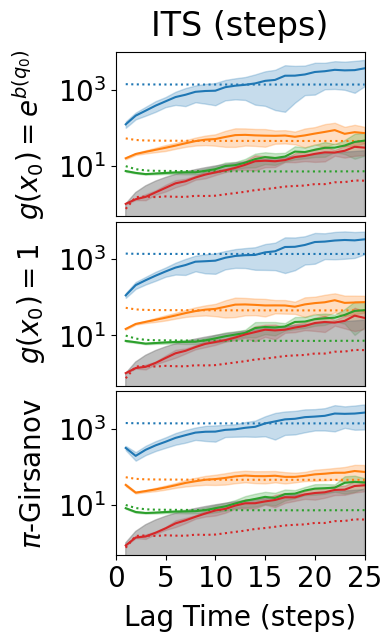

In [8]:
# Plot ITS
s = 15
ms = 5
nrows = 3
ncols = 1

labels = ['$g(x_0)=e^{b(q_0)}$','$g(x_0) =1$','$\pi$-Girsanov']
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig,ax = plt.subplots(nrows=nrows,ncols=ncols,figsize=(4,6.5))

for i in range(nrows):
    for n in range(n_processes):
        ax[i].plot(its_lagtimes,its_ref[n],color=colors[n],linestyle=':')
        ax[i].plot(its_lagtimes,its_mean[i,n,:],color=colors[n])
        ax[i].fill_between(its_lagtimes,its_mean[i,n,:]-its_std[i,n,:],its_mean[i,n,:]+its_std[i,n,:],alpha=0.25,color=colors[n])
    ax[i].fill_between(its_lagtimes, np.full((len(its_lagtimes),),fill_value=ax[i].get_ylim()[0]), its_lagtimes, alpha=0.5, color='grey')
    ax[i].set_yscale('log')
    ax[i].set_xlim([0,its_lagtimes[-1]])
    ax[i].set_xticks(np.linspace(0,its_lagtimes[-1],6))
    ax[i].set_ylabel(labels[i],labelpad=8)
    # Cleaner labels
    if i < nrows-1:
        ax[i].tick_params(bottom=False, labelbottom=False)

ax[0].set_title('ITS (steps)',pad=12)
ax[2].set_xlabel('Lag Time (steps)',labelpad=8)  

# Use Uniform Scales: apply the one with the largest range to all
diff = np.zeros(nrows,)
for i in range(nrows):
    diff[i] = ax[i].get_ylim()[1]-ax[i].get_ylim()[0]
idx = np.where(diff == diff.max())[0][0]
for i in range(nrows):
    ax[i].set_ylim(ax[idx].get_ylim())


plt.tight_layout(pad=0.5, w_pad=0.2, h_pad=0.2)
plt.savefig('figures/{name}/rerun_its.png'.format(name=name),dpi=600)
plt.show()

In [9]:
# Reference MSM
msm_lagtime = 8
msm_ref = build_MSM(msm_lagtime,assignments_ref)

ev = np.zeros((3, n_repeats, n_microstates, n_eigenvectors))

for n_re in range(n_repeats):
    assignments, empty_states = assignments_rerun[n_re]
    # Use Boltzmann factor for the path initial point as g factor, i.e. g(x0) = e^{b^k(x0)}
    reweighting_factors = (data_rerun[n_re][:,1],data_rerun[n_re][:,2])
    msm = Girsanov_MSM(msm_lagtime,assignments,reweighting_factors)
    ev[0,n_re,:,:] = reorganize_eigenvectors(msm,msm_ref,n_eigenvectors,n_microstates,empty_states)
    # Ignore g factor, i.e. g(x0) = 1
    reweighting_factors = (np.ones(data_rerun[n_re][:,1].shape),data_rerun[n_re][:,2])
    msm = Girsanov_MSM(msm_lagtime,assignments,reweighting_factors)
    ev[1,n_re,:,:] = reorganize_eigenvectors(msm,msm_ref,n_eigenvectors,n_microstates,empty_states)
    # Ignore g, but optimize the MSM with a stationary vector constraint
    histogram = np.bincount(assignments,weights=data_rerun[n_re][:,1])
    stationary_pi = histogram / np.sum(histogram)
    msm = Girsanov_MSM(msm_lagtime,assignments,reweighting_factors,stationary_pi=stationary_pi)
    ev[2,n_re,:,:] = reorganize_eigenvectors(msm,msm_ref,n_eigenvectors,n_microstates,empty_states)

ev_mean = np.nanmean(ev,axis=1)
ev_std = np.nanstd(ev,axis=1)

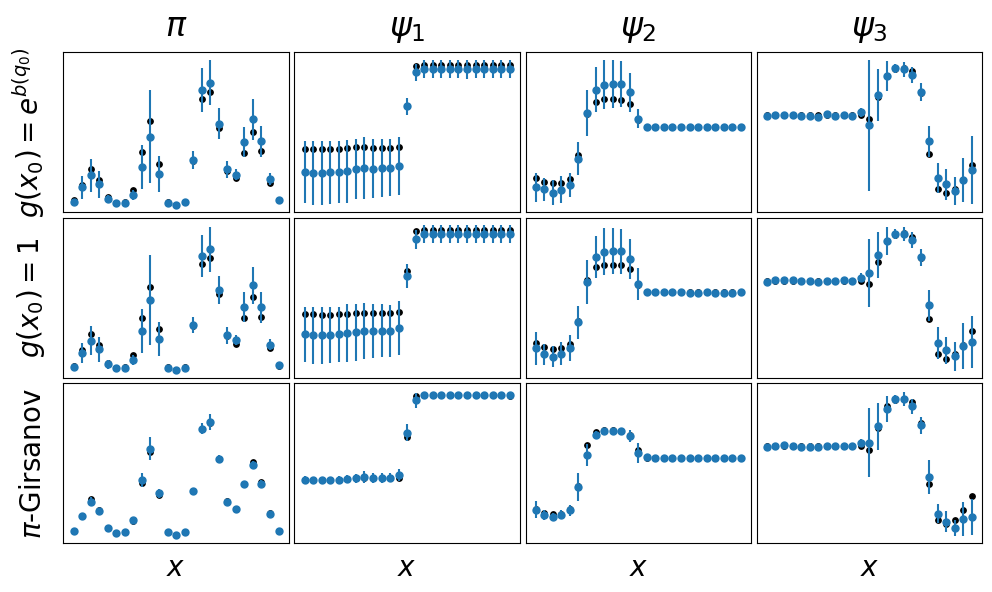

In [11]:
# Plot Eigenvectors
s = 15
ms = 5
nrows = 3
ncols = 4

labels = ['$g(x_0)=e^{b(q_0)}$','$g(x_0) =1$','$\pi$-Girsanov']

fig,ax = plt.subplots(nrows=nrows,ncols=ncols,figsize=(10,6))

for i in range(nrows):
    # Plot reference
    ax[i,0].scatter(microstates.cluster_centers,msm_ref.stationary_distribution,s=s,color='black')
    ax[i,0].errorbar(microstates.cluster_centers,ev_mean[i,:,0],yerr=ev_std[i,:,0],fmt='o',ms=ms)
    for j in range(1,ncols):
        # Plot reference
        ax[i,j].scatter(microstates.cluster_centers,msm_ref.eigenvectors_right()[:,j],s=s,label='Ref',color='black')
        # Compare each ev with the ref, ensure the alignment/average is correct
        #ax[i,j].scatter(microstates.cluster_centers,ev[i,2,:,j],s=s,color='red')
        ax[i,j].errorbar(microstates.cluster_centers,ev_mean[i,:,j],yerr=ev_std[i,:,j],fmt='o',ms=ms,label=labels[i])
    # Cleaner labels
    if i < nrows-1:
        for j in range(ncols):
            ax[i,j].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    else:
        for j in range(ncols):
            ax[nrows-1,j].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
            ax[nrows-1,j].set_xlabel('$x$',labelpad=8)

    ax[i,0].set_ylabel(labels[i],labelpad=12)

# Cleaner labels
ax[0,0].set_title('$\pi$',pad=12)
ax[0,1].set_title('$\psi_1$',pad=12)
ax[0,2].set_title('$\psi_2$',pad=12)
ax[0,3].set_title('$\psi_3$',pad=12)

# Use Uniform Scales: apply the one with the largest range to all
for j in range(ncols):
    range_j = np.zeros(nrows,)
    for i in range(nrows):
        range_j[i] = ax[i,j].get_ylim()[1]-ax[i,j].get_ylim()[0]
    idx = np.where(range_j == range_j.max())[0][0]
    for i in range(nrows):
        ax[i,j].set_ylim(ax[idx,j].get_ylim())
    
plt.tight_layout(pad=0.5, w_pad=0.2, h_pad=0.2)
plt.savefig('figures/{name}/rerun_ev.png'.format(name=name),dpi=600)
plt.show()

##### 1.2 Metadynamics Build-up

In [12]:
# Evaluate Implied Timescales
n_processes = n_eigenvectors        # Display one extra trivial process
its_lagtimes = np.array(np.linspace(1,25,25),dtype=np.int32)
its = np.zeros((3,n_repeats,n_processes,len(its_lagtimes)))

for n_re in range(n_repeats):
    assignments, empty_states = assignments_build_up[n_re]
    # ITS - Use Boltzmann factor for the path initial point as g factor, i.e. g(x0) = e^{b^k(x0)}
    reweighting_factors = (data_build_up[n_re][:,1],data_build_up[n_re][:,2])
    models = []
    for its_lagtime in its_lagtimes:
        #print(its_lagtime)
        count_estimator = GirsanovReweightingEstimator(lagtime=its_lagtime,count_mode='sliding')
        counts = count_estimator.fit(data=assignments,reweighting_factors=reweighting_factors).fetch_model()
        models.append(MaximumLikelihoodMSM().fit_fetch(counts))
    its_data = implied_timescales(models)
    for i in range(n_processes):
        its[0,n_re,i,:] = its_data.timescales_for_process(i)
    # ITS - Ignore g factor, i.e. g(x0) = 1
    reweighting_factors = (np.ones(data_build_up[n_re][:,1].shape),data_build_up[n_re][:,2])
    models = []
    for its_lagtime in its_lagtimes:
        #print(its_lagtime)
        count_estimator = GirsanovReweightingEstimator(lagtime=its_lagtime,count_mode='sliding')
        counts = count_estimator.fit(data=assignments,reweighting_factors=reweighting_factors).fetch_model()
        models.append(MaximumLikelihoodMSM().fit_fetch(counts))
    its_data = implied_timescales(models)
    for i in range(n_processes):
        its[1,n_re,i,:] = its_data.timescales_for_process(i)
    # ITS - Ignore g, but optimize the MSM with a stationary vector constraint
    histogram = np.bincount(assignments,weights=data_build_up[n_re][:,1])
    stationary_pi = histogram / np.sum(histogram)
 
    models = []
    for its_lagtime in its_lagtimes:
        #print(its_lagtime)
        count_estimator = GirsanovReweightingEstimator(lagtime=its_lagtime,count_mode='sliding')
        counts = count_estimator.fit(data=assignments,reweighting_factors=reweighting_factors).fetch_model()
        models.append(MaximumLikelihoodMSM(stationary_distribution_constraint=stationary_pi).fit_fetch(counts))
    its_data = implied_timescales(models)
    for i in range(n_processes):
        its[2,n_re,i,:] = its_data.timescales_for_process(i)

# Reference ITS
its_ref = np.zeros((n_processes,len(its_lagtimes)))
models = []
for its_lagtime in its_lagtimes:
    counts = TransitionCountEstimator(lagtime=its_lagtime, count_mode='sliding').fit_fetch(assignments_ref)
    models.append(MaximumLikelihoodMSM().fit_fetch(counts))
its_data = implied_timescales(models)
for i in range(n_processes):
    its_ref[i,:] = its_data.timescales_for_process(i)

its_mean = np.mean(its,axis=1)
its_std = np.std(its,axis=1)

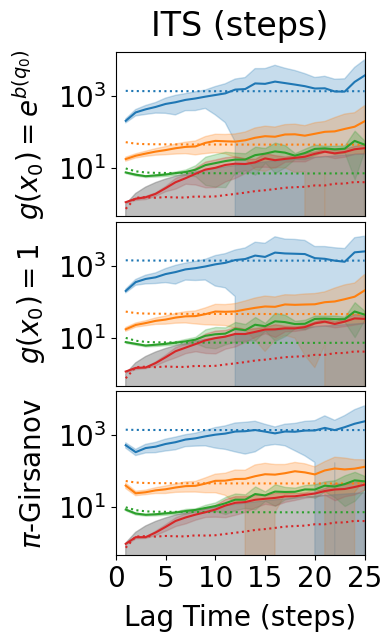

In [13]:
# Plot ITS
s = 15
ms = 5
nrows = 3
ncols = 1

labels = ['$g(x_0)=e^{b(q_0)}$','$g(x_0) =1$','$\pi$-Girsanov']
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig,ax = plt.subplots(nrows=nrows,ncols=ncols,figsize=(4,6.5))

for i in range(nrows):
    for n in range(n_processes):
        ax[i].plot(its_lagtimes,its_ref[n],color=colors[n],linestyle=':')
        ax[i].plot(its_lagtimes,its_mean[i,n,:],color=colors[n])
        ax[i].fill_between(its_lagtimes,its_mean[i,n,:]-its_std[i,n,:],its_mean[i,n,:]+its_std[i,n,:],alpha=0.25,color=colors[n])
    ax[i].fill_between(its_lagtimes, np.full((len(its_lagtimes),),fill_value=ax[i].get_ylim()[0]), its_lagtimes, alpha=0.5, color='grey')
    ax[i].set_yscale('log')
    ax[i].set_xlim([0,its_lagtimes[-1]])
    ax[i].set_xticks(np.linspace(0,its_lagtimes[-1],6))
    ax[i].set_ylabel(labels[i],labelpad=8)
    # Cleaner labels
    ax[i].set_yticks([10,1000])
    if i < nrows-1:
        ax[i].tick_params(bottom=False, labelbottom=False)

ax[0].set_title('ITS (steps)',pad=12)
ax[2].set_xlabel('Lag Time (steps)',labelpad=8)

# Use Uniform Scales: apply the one with the largest range to all
diff = np.zeros(nrows,)
for i in range(nrows):
    diff[i] = ax[i].get_ylim()[1]-ax[i].get_ylim()[0]
idx = np.where(diff == diff.max())[0][0]
for i in range(nrows):
    ax[i].set_ylim(ax[idx].get_ylim())


plt.tight_layout(pad=0.5, w_pad=0.2, h_pad=0.2)
plt.savefig('figures/{name}/build_up_its.png'.format(name=name),dpi=600)
plt.show()

In [14]:
# Reference MSM
msm_lagtime = 8
msm_ref = build_MSM(msm_lagtime,assignments_ref)

ev = np.zeros((3, n_repeats, n_microstates, n_eigenvectors))

for n_re in range(n_repeats):
    assignments, empty_states = assignments_build_up[n_re]
    # Use Boltzmann factor for the path initial point as g factor, i.e. g(x0) = e^{b^k(x0)}
    reweighting_factors = (data_build_up[n_re][:,1],data_build_up[n_re][:,2])
    msm = Girsanov_MSM(msm_lagtime,assignments,reweighting_factors)
    ev[0,n_re,:,:] = reorganize_eigenvectors(msm,msm_ref,n_eigenvectors,n_microstates,empty_states)
    # Ignore g factor, i.e. g(x0) = 1
    reweighting_factors = (np.ones(data_build_up[n_re][:,1].shape),data_build_up[n_re][:,2])
    msm = Girsanov_MSM(msm_lagtime,assignments,reweighting_factors)
    ev[1,n_re,:,:] = reorganize_eigenvectors(msm,msm_ref,n_eigenvectors,n_microstates,empty_states)
    # Ignore g, but optimize the MSM with a stationary vector constraint
    histogram = np.bincount(assignments,weights=data_build_up[n_re][:,1])
    stationary_pi = histogram / np.sum(histogram)
    msm = Girsanov_MSM(msm_lagtime,assignments,reweighting_factors,stationary_pi=stationary_pi)
    ev[2,n_re,:,:] = reorganize_eigenvectors(msm,msm_ref,n_eigenvectors,n_microstates,empty_states)

ev_mean = np.nanmean(ev,axis=1)
ev_std = np.nanstd(ev,axis=1)

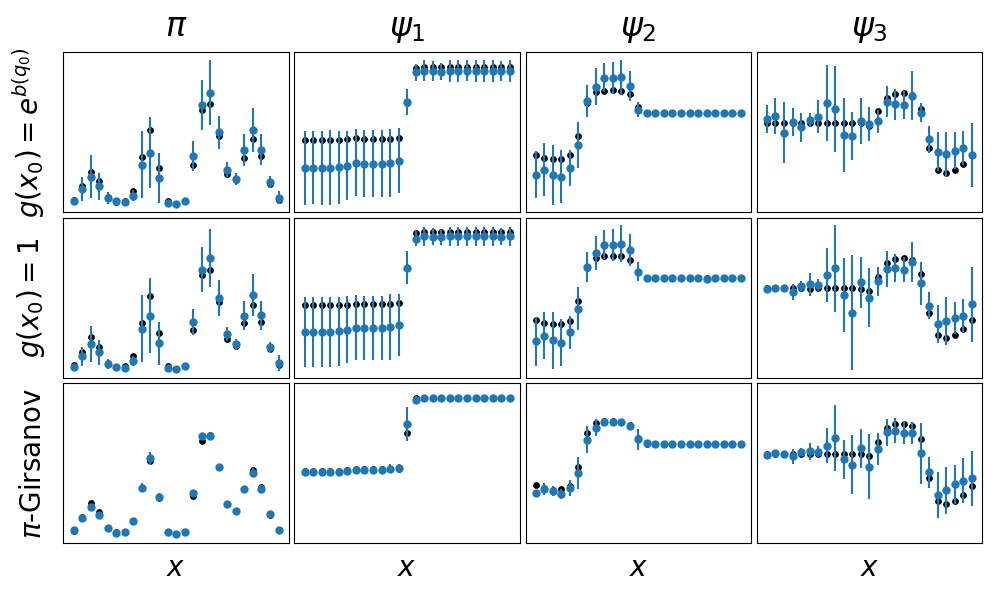

In [15]:
# Plot Eigenvectors
s = 15
ms = 5
nrows = 3
ncols = 4

labels = ['$g(x_0)=e^{b(q_0)}$','$g(x_0) =1$','$\pi$-Girsanov']

fig,ax = plt.subplots(nrows=nrows,ncols=ncols,figsize=(10,6))

for i in range(nrows):
    # Plot reference
    ax[i,0].scatter(microstates.cluster_centers,msm_ref.stationary_distribution,s=s,color='black')
    ax[i,0].errorbar(microstates.cluster_centers,ev_mean[i,:,0],yerr=ev_std[i,:,0],fmt='o',ms=ms)
    for j in range(1,ncols):
        # Plot reference
        ax[i,j].scatter(microstates.cluster_centers,msm_ref.eigenvectors_right()[:,j],s=s,label='Ref',color='black')
        # Compare each ev with the ref, ensure the alignment/average is correct
        #ax[i,j].scatter(microstates.cluster_centers,ev[i,2,:,j],s=s,color='red')
        ax[i,j].errorbar(microstates.cluster_centers,ev_mean[i,:,j],yerr=ev_std[i,:,j],fmt='o',ms=ms,label=labels[i])
    # Cleaner labels
    if i < nrows-1:
        for j in range(ncols):
            ax[i,j].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    else:
        for j in range(ncols):
            ax[nrows-1,j].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
            ax[nrows-1,j].set_xlabel('$x$',labelpad=8)

    ax[i,0].set_ylabel(labels[i],labelpad=12)

# Cleaner labels
ax[0,0].set_title('$\pi$',pad=12)
ax[0,1].set_title('$\psi_1$',pad=12)
ax[0,2].set_title('$\psi_2$',pad=12)
ax[0,3].set_title('$\psi_3$',pad=12)

# Use Uniform Scales: apply the one with the largest range to all
for j in range(ncols):
    range_j = np.zeros(nrows,)
    for i in range(nrows):
        range_j[i] = ax[i,j].get_ylim()[1]-ax[i,j].get_ylim()[0]
    idx = np.where(range_j == range_j.max())[0][0]
    for i in range(nrows):
        ax[i,j].set_ylim(ax[idx,j].get_ylim())
    
plt.tight_layout(pad=0.5, w_pad=0.2, h_pad=0.2)
plt.savefig('figures/{name}/build_up_ev.png'.format(name=name),dpi=600)
plt.show()

##### 1.3 Umbrella Sampling

In [ ]:
# Evaluate Implied Timescales
n_processes = n_eigenvectors        # Display one extra trivial process
its_lagtimes = np.array(np.linspace(1,10,10),dtype=np.int32)
its = np.zeros((3,n_repeats,n_processes,len(its_lagtimes)))

# Umbrella sampling/MBAR related
# Spring constant
k_spring = 100
# Window centers
n_windows = 50
x_min = -0.8
x_max = 0.8
window_centers = np.linspace(x_min,x_max,n_windows)
n_samples_per_window = data_us[0][:,:,0].shape[1]
temp = 298.15
# We do not have unbiased simulation data in this dataset, so compute unbiased weights with no samples
unbiased = True

for n_re in range(n_repeats):
    assignments, empty_states = assignments_us[n_re]
    # ITS - Use MBAR weights as g(x0)
    # Compute MBAR weights for all samples
    u_kn, N_k = us_mbar_input(
        data_us[n_re][:,:,0].reshape(-1,), window_centers, k_spring, n_samples_per_window, unbiased, temp
    )
    # Fit MBAR
    mbar = MBAR(u_kn, N_k)
    sample_weights = mbar.W_nk[:,0]
    # Use MBAR factor for the path initial point as g factor
    reweighting_factors = (sample_weights.reshape(data_us[n_re][:,:,1].shape),data_us[n_re][:,:,2])
    
    models = []
    for its_lagtime in its_lagtimes:
        #print(its_lagtime)
        count_estimator = GirsanovReweightingEstimator(lagtime=its_lagtime,count_mode='sliding')
        counts = count_estimator.fit(data=assignments,reweighting_factors=reweighting_factors).fetch_model()
        models.append(MaximumLikelihoodMSM().fit_fetch(counts))
    its_data = implied_timescales(models)
    for i in range(n_processes):
        its[0,n_re,i,:] = its_data.timescales_for_process(i)
    # ITS - Ignore g factor, i.e. g(x0) = 1
    reweighting_factors = (np.ones(data_us[n_re][:,:,1].shape),data_us[n_re][:,:,2])
    models = []
    for its_lagtime in its_lagtimes:
        #print(its_lagtime)
        count_estimator = GirsanovReweightingEstimator(lagtime=its_lagtime,count_mode='sliding')
        counts = count_estimator.fit(data=assignments,reweighting_factors=reweighting_factors).fetch_model()
        models.append(MaximumLikelihoodMSM().fit_fetch(counts))
    its_data = implied_timescales(models)
    for i in range(n_processes):
        its[1,n_re,i,:] = its_data.timescales_for_process(i)
    # ITS - Ignore g, but optimize the MSM with a stationary vector constraint
    # Estimate a weighted histogram with MBAR weights
    histogram = np.bincount(np.concatenate(assignments_us[n_re][0]),weights=sample_weights)
    stationary_pi = histogram / np.sum(histogram)
    
    models = []
    for its_lagtime in its_lagtimes:
        #print(its_lagtime)
        count_estimator = GirsanovReweightingEstimator(lagtime=its_lagtime,count_mode='sliding')
        counts = count_estimator.fit(data=assignments,reweighting_factors=reweighting_factors).fetch_model()
        models.append(MaximumLikelihoodMSM(stationary_distribution_constraint=stationary_pi).fit_fetch(counts))
    its_data = implied_timescales(models)
    for i in range(n_processes):
        its[2,n_re,i,:] = its_data.timescales_for_process(i)

# Reference ITS
its_ref = np.zeros((n_processes,len(its_lagtimes)))
models = []
for its_lagtime in its_lagtimes:
    counts = TransitionCountEstimator(lagtime=its_lagtime, count_mode='sliding').fit_fetch(assignments_ref)
    models.append(MaximumLikelihoodMSM().fit_fetch(counts))
its_data = implied_timescales(models)
for i in range(n_processes):
    its_ref[i,:] = its_data.timescales_for_process(i)

its_mean = np.mean(its,axis=1)
its_std = np.std(its,axis=1)

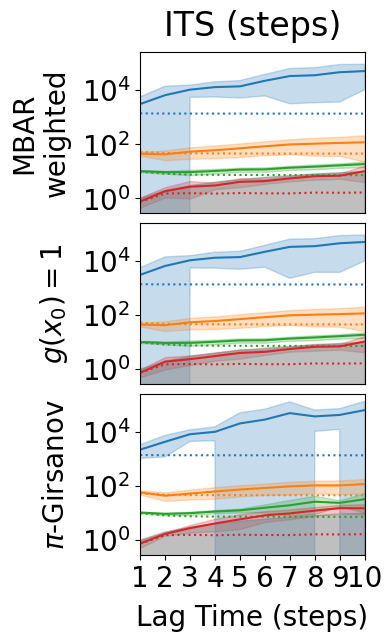

In [20]:
# Plot ITS
s = 15
ms = 5
nrows = 3
ncols = 1

labels = ['MBAR\nweighted','$g(x_0) =1$','$\pi$-Girsanov']
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig,ax = plt.subplots(nrows=nrows,ncols=ncols,figsize=(4,6.5))

for i in range(nrows):
    for n in range(n_processes):
        ax[i].plot(its_lagtimes,its_ref[n],color=colors[n],linestyle=':')
        ax[i].plot(its_lagtimes,its_mean[i,n,:],color=colors[n])
        ax[i].fill_between(its_lagtimes,its_mean[i,n,:]-its_std[i,n,:],its_mean[i,n,:]+its_std[i,n,:],alpha=0.25,color=colors[n])
    ax[i].fill_between(its_lagtimes, np.full((len(its_lagtimes),),fill_value=ax[i].get_ylim()[0]), its_lagtimes, alpha=0.5, color='grey')
    ax[i].set_yscale('log')
    ax[i].set_xlim([1,its_lagtimes[-1]])
    ax[i].set_xticks(np.linspace(1,its_lagtimes[-1],10))
    ax[i].set_ylabel(labels[i],labelpad=8)
    # Cleaner labels
    ax[i].set_yticks([1,100,10000])
    if i < nrows-1:
        ax[i].tick_params(bottom=False, labelbottom=False)

ax[0].set_title('ITS (steps)',pad=12)
ax[2].set_xlabel('Lag Time (steps)',labelpad=8)

# Use Uniform Scales: apply the one with the largest range to all
diff = np.zeros(nrows,)
for i in range(nrows):
    diff[i] = ax[i].get_ylim()[1]-ax[i].get_ylim()[0]
idx = np.where(diff == diff.max())[0][0]
for i in range(nrows):
    ax[i].set_ylim(ax[idx].get_ylim())

plt.tight_layout(pad=0.5, w_pad=0.2, h_pad=0.2)
plt.savefig('figures/{name}/us_its.png'.format(name=name),dpi=600)
plt.show()

In [170]:
# Reference MSM
msm_lagtime = 1
msm_ref = build_MSM(msm_lagtime,assignments_ref)

ev = np.zeros((3, n_repeats, n_microstates, n_eigenvectors))

for n_re in range(n_repeats):
    assignments, empty_states = assignments_us[n_re]
    # Compute MBAR weights for all samples
    u_kn, N_k = us_mbar_input(
        data_us[n_re][:,:,0].reshape(-1,), window_centers, k_spring, n_samples_per_window, unbiased, temp
    )
    # Fit MBAR
    mbar = MBAR(u_kn, N_k)
    sample_weights = mbar.W_nk[:,0]
    # Use MBAR factor for the path initial point as g factor
    reweighting_factors = (sample_weights.reshape(data_us[n_re][:,:,1].shape),data_us[n_re][:,:,2])
    msm = Girsanov_MSM(msm_lagtime,assignments,reweighting_factors)
    ev[0,n_re,:,:] = reorganize_eigenvectors(msm,msm_ref,n_eigenvectors,n_microstates,empty_states)
    # Ignore g factor, i.e. g(x0) = 1
    reweighting_factors = (np.ones(data_us[n_re][:,:,1].shape),data_us[n_re][:,:,2])
    msm = Girsanov_MSM(msm_lagtime,assignments,reweighting_factors)
    ev[1,n_re,:,:] = reorganize_eigenvectors(msm,msm_ref,n_eigenvectors,n_microstates,empty_states)
    # Ignore g, but optimize the MSM with a stationary vector constraint
    # Estimate a weighted histogram with MBAR weights
    histogram = np.bincount(np.concatenate(assignments_us[n_re][0]),weights=sample_weights)
    stationary_pi = histogram / np.sum(histogram)
    msm = Girsanov_MSM(msm_lagtime,assignments,reweighting_factors,stationary_pi=stationary_pi)
    ev[2,n_re,:,:] = reorganize_eigenvectors(msm,msm_ref,n_eigenvectors,n_microstates,empty_states)

ev_mean = np.nanmean(ev,axis=1)
ev_std = np.nanstd(ev,axis=1)

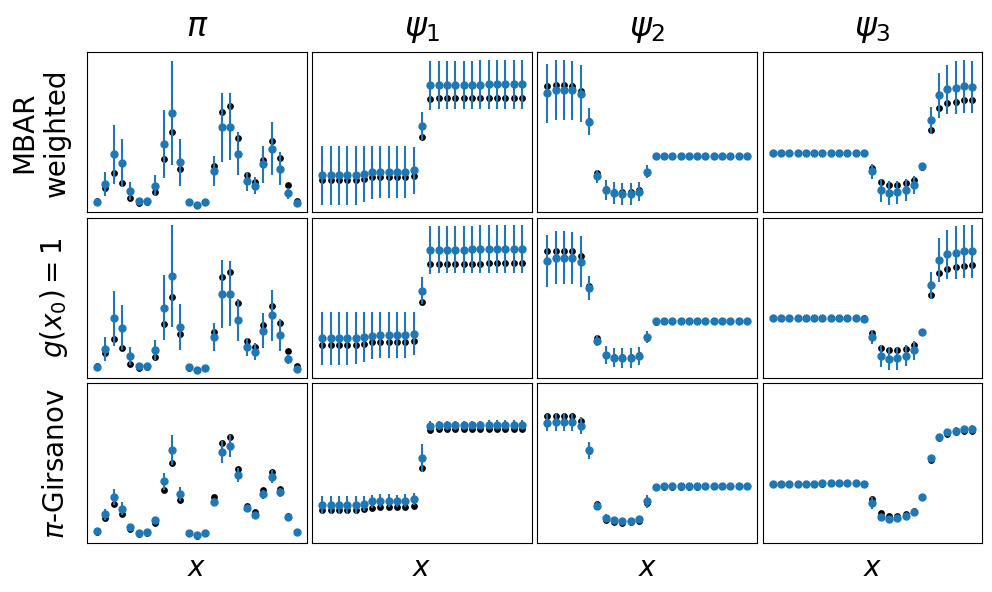

In [171]:
# Plot Eigenvectors
s = 15
ms = 5
nrows = 3
ncols = 4

labels = ['MBAR\nweighted','$g(x_0) =1$','$\pi$-Girsanov']

fig,ax = plt.subplots(nrows=nrows,ncols=ncols,figsize=(10,6))

for i in range(nrows):
    # Plot reference
    ax[i,0].scatter(microstates.cluster_centers,msm_ref.stationary_distribution,s=s,color='black')
    ax[i,0].errorbar(microstates.cluster_centers,ev_mean[i,:,0],yerr=ev_std[i,:,0],fmt='o',ms=ms)
    for j in range(1,ncols):
        # Plot reference
        ax[i,j].scatter(microstates.cluster_centers,msm_ref.eigenvectors_right()[:,j],s=s,label='Ref',color='black')
        # Compare each ev with the ref, ensure the alignment/average is correct
        #ax[i,j].scatter(microstates.cluster_centers,ev[i,2,:,j],s=s,color='red')
        ax[i,j].errorbar(microstates.cluster_centers,ev_mean[i,:,j],yerr=ev_std[i,:,j],fmt='o',ms=ms,label=labels[i])
    # Cleaner labels
    if i < nrows-1:
        for j in range(ncols):
            ax[i,j].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    else:
        for j in range(ncols):
            ax[nrows-1,j].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
            ax[nrows-1,j].set_xlabel('$x$',labelpad=8)

    ax[i,0].set_ylabel(labels[i],labelpad=12)

# Cleaner labels
ax[0,0].set_title('$\pi$',pad=12)
ax[0,1].set_title('$\psi_1$',pad=12)
ax[0,2].set_title('$\psi_2$',pad=12)
ax[0,3].set_title('$\psi_3$',pad=12)

# Use Uniform Scales: apply the one with the largest range to all
for j in range(ncols):
    range_j = np.zeros(nrows,)
    for i in range(nrows):
        range_j[i] = ax[i,j].get_ylim()[1]-ax[i,j].get_ylim()[0]
    idx = np.where(range_j == range_j.max())[0][0]
    for i in range(nrows):
        ax[i,j].set_ylim(ax[idx,j].get_ylim())
    
plt.tight_layout(pad=0.5, w_pad=0.2, h_pad=0.2)
plt.savefig('figures/{name}/us_ev.png'.format(name=name),dpi=600)
plt.show()

##### 1.4 Steered MD

In [21]:
# Evaluate Implied Timescales
n_processes = n_eigenvectors        # Display one extra trivial process
its_lagtimes = np.array(np.linspace(1,10,10),dtype=np.int32)
#its_lagtimes = [1,2,3,5,7]
its = np.zeros((2,n_repeats,n_processes,len(its_lagtimes)))
# For now we use analytical potential, consider compute this with Jarzynski's equality
kt = 8.314 * temp / 1000
stationary_pi = np.exp(systemforce.potential(microstates.cluster_centers)/(-kt))
stationary_pi = (stationary_pi / stationary_pi.sum()).reshape(-1,)

for n_re in range(n_repeats):
    assignments, empty_states = assignments_smd[n_re]
    # ITS - Ignore g factor, i.e. g(x0) = 1
    reweighting_factors = (np.ones(data_smd[n_re][:,1].shape),data_smd[n_re][:,1])
    models = []
    for its_lagtime in its_lagtimes:
        #print(its_lagtime)
        count_estimator = GirsanovReweightingEstimator(lagtime=its_lagtime,count_mode='sliding')
        counts = count_estimator.fit(data=assignments,reweighting_factors=reweighting_factors).fetch_model()
        models.append(MaximumLikelihoodMSM().fit_fetch(counts))
    its_data = implied_timescales(models)
    for i in range(n_processes):
        its[0,n_re,i,:] = its_data.timescales_for_process(i)
    # ITS - Ignore g, but optimize the MSM with a stationary vector constraint
    models = []
    for its_lagtime in its_lagtimes:
        #print(its_lagtime)
        count_estimator = GirsanovReweightingEstimator(lagtime=its_lagtime,count_mode='sliding')
        counts = count_estimator.fit(data=assignments,reweighting_factors=reweighting_factors).fetch_model()
        models.append(MaximumLikelihoodMSM(stationary_distribution_constraint=stationary_pi).fit_fetch(counts))
    its_data = implied_timescales(models)
    for i in range(n_processes):
        its[1,n_re,i,:] = its_data.timescales_for_process(i)

# Reference ITS
its_ref = np.zeros((n_processes,len(its_lagtimes)))
models = []
for its_lagtime in its_lagtimes:
    counts = TransitionCountEstimator(lagtime=its_lagtime, count_mode='sliding').fit_fetch(assignments_ref)
    models.append(MaximumLikelihoodMSM().fit_fetch(counts))
its_data = implied_timescales(models)
for i in range(n_processes):
    its_ref[i,:] = its_data.timescales_for_process(i)

its_mean = np.mean(its,axis=1)
its_std = np.std(its,axis=1)

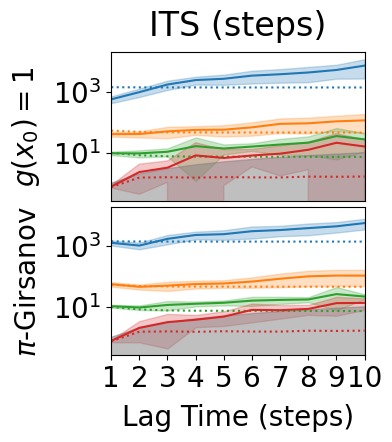

In [22]:
# Plot ITS
s = 15
ms = 5
nrows = 2
ncols = 1

labels = ['$g(x_0) =1$','$\pi$-Girsanov']
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig,ax = plt.subplots(nrows=nrows,ncols=ncols,figsize=(4,4.5))

for i in range(nrows):
    for n in range(n_processes):
        ax[i].plot(its_lagtimes,its_ref[n],color=colors[n],linestyle=':')
        ax[i].plot(its_lagtimes,its_mean[i,n,:],color=colors[n])
        ax[i].fill_between(its_lagtimes,its_mean[i,n,:]-its_std[i,n,:],its_mean[i,n,:]+its_std[i,n,:],alpha=0.25,color=colors[n])
    ax[i].fill_between(its_lagtimes, np.full((len(its_lagtimes),),fill_value=ax[i].get_ylim()[0]), its_lagtimes, alpha=0.5, color='grey')
    ax[i].set_yscale('log')
    ax[i].set_xlim([1,its_lagtimes[-1]])
    ax[i].set_xticks(np.linspace(1,its_lagtimes[-1],10))
    ax[i].set_ylabel(labels[i],labelpad=8)
    # Cleaner labels
    ax[i].set_yticks([10,1000])
    if i < nrows-1:
        ax[i].tick_params(bottom=False, labelbottom=False)

ax[0].set_title('ITS (steps)',pad=12)
ax[1].set_xlabel('Lag Time (steps)',labelpad=8) 

# Use Uniform Scales: apply the one with the largest range to all
diff = np.zeros(nrows,)
for i in range(nrows):
    diff[i] = ax[i].get_ylim()[1]-ax[i].get_ylim()[0]
idx = np.where(diff == diff.max())[0][0]
for i in range(nrows):
    ax[i].set_ylim(ax[idx].get_ylim())

plt.tight_layout(pad=0.5, w_pad=0.2, h_pad=0.2)
plt.savefig('figures/{name}/smd_its.png'.format(name=name),dpi=600)
plt.show()

In [178]:
# Reference MSM
msm_lagtime = 5
msm_ref = build_MSM(msm_lagtime,assignments_ref)

ev = np.zeros((2, n_repeats, n_microstates, n_eigenvectors))
# For now we use analytical potential, consider compute this with Jarzynski's equality
kt = 8.314 * temp / 1000
stationary_pi = np.exp(systemforce.potential(microstates.cluster_centers)/(-kt))
stationary_pi = (stationary_pi / stationary_pi.sum()).reshape(-1,)

for n_re in range(n_repeats):
    assignments, empty_states = assignments_smd[n_re]
    # Ignore g factor, i.e. g(x0) = 1
    reweighting_factors = (np.ones(data_smd[n_re][:,1].shape),data_smd[n_re][:,1])
    msm = Girsanov_MSM(msm_lagtime,assignments,reweighting_factors)
    ev[0,n_re,:,:] = reorganize_eigenvectors(msm,msm_ref,n_eigenvectors,n_microstates,empty_states)
    # Ignore g, but optimize the MSM with a stationary vector constraint
    msm = Girsanov_MSM(msm_lagtime,assignments,reweighting_factors,stationary_pi=stationary_pi)
    ev[1,n_re,:,:] = reorganize_eigenvectors(msm,msm_ref,n_eigenvectors,n_microstates,empty_states)

ev_mean = np.nanmean(ev,axis=1)
ev_std = np.nanstd(ev,axis=1)

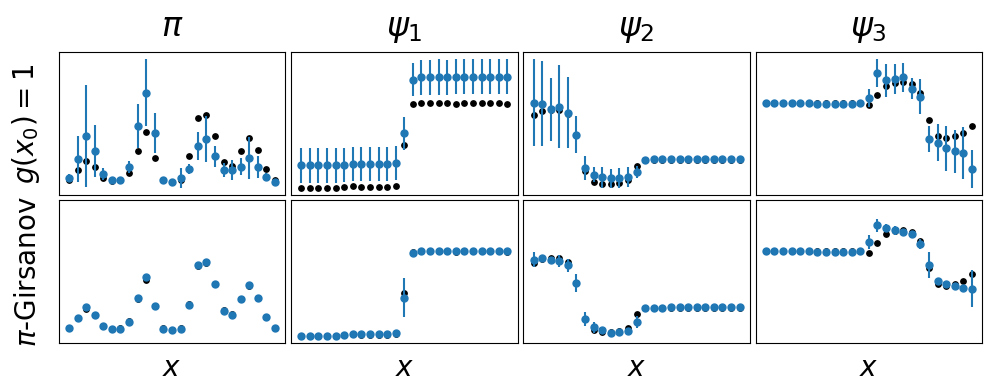

In [179]:
# Plot Eigenvectors
s = 15
ms = 5
nrows = 2
ncols = 4

labels = ['$g(x_0) =1$','$\pi$-Girsanov']

fig,ax = plt.subplots(nrows=nrows,ncols=ncols,figsize=(10,4))

for i in range(nrows):
    # Plot reference
    ax[i,0].scatter(microstates.cluster_centers,msm_ref.stationary_distribution,s=s,color='black')
    ax[i,0].errorbar(microstates.cluster_centers,ev_mean[i,:,0],yerr=ev_std[i,:,0],fmt='o',ms=ms)
    for j in range(1,ncols):
        # Plot reference
        ax[i,j].scatter(microstates.cluster_centers,msm_ref.eigenvectors_right()[:,j],s=s,label='Ref',color='black')
        # Compare each ev with the ref, ensure the alignment/average is correct
        #ax[i,j].scatter(microstates.cluster_centers,ev[i,2,:,j],s=s,color='red')
        ax[i,j].errorbar(microstates.cluster_centers,ev_mean[i,:,j],yerr=ev_std[i,:,j],fmt='o',ms=ms,label=labels[i])
    # Cleaner labels
    if i < nrows-1:
        for j in range(ncols):
            ax[i,j].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    else:
        for j in range(ncols):
            ax[nrows-1,j].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
            ax[nrows-1,j].set_xlabel('$x$',labelpad=8)

    ax[i,0].set_ylabel(labels[i],labelpad=12)

# Cleaner labels
ax[0,0].set_title('$\pi$',pad=12)
ax[0,1].set_title('$\psi_1$',pad=12)
ax[0,2].set_title('$\psi_2$',pad=12)
ax[0,3].set_title('$\psi_3$',pad=12)

# Use Uniform Scales: apply the one with the largest range to all
for j in range(ncols):
    range_j = np.zeros(nrows,)
    for i in range(nrows):
        range_j[i] = ax[i,j].get_ylim()[1]-ax[i,j].get_ylim()[0]
    idx = np.where(range_j == range_j.max())[0][0]
    for i in range(nrows):
        ax[i,j].set_ylim(ax[idx,j].get_ylim())
    
plt.tight_layout(pad=0.5, w_pad=0.2, h_pad=0.2)
plt.savefig('figures/{name}/smd_ev.png'.format(name=name),dpi=600)
plt.show()